# 05 — Model Training  *(corrected pipeline)*

**Corrections applied:**
1. **Macro demeaning**: expanding mean (not full-sample) — removes future-info leakage
2. **scale_pos_weight**: computed per CV fold on training data only
3. **M1b** (LR with lag1-3) added to main comparison for clean identification
4. **Calibration plot** added

Input: `data/processed/jst_sentiment_master.csv`
Output: `data/processed/sentiment_improved/`


## Cell 1 — Imports and Paths

In [1]:
import os, warnings, tempfile
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay)
import xgboost as xgb
import shap

BASE     = Path(r'C:\Users\Owner\OneDrive\dissertation')
DATA_IN  = BASE / 'data' / 'processed' / 'jst_sentiment_master.csv'
OUT_DIR  = BASE / 'data' / 'processed' / 'sentiment_improved'
FIG_DIR  = BASE / 'figures' / 'sentiment_improved'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

assert DATA_IN.exists(), f'Input not found: {DATA_IN}'
print('=' * 65)
print(' 05 — MODEL TRAINING (sentiment_improved)')
print('=' * 65)
print(f'Input  : {DATA_IN}')
print(f'OutDir : {OUT_DIR}')
print(f'FigDir : {FIG_DIR}')
print()
print(f'numpy {np.__version__} | xgboost {xgb.__version__} | shap {shap.__version__}')

 05 — MODEL TRAINING (sentiment_improved)
Input  : C:\Users\Owner\OneDrive\dissertation\data\processed\jst_sentiment_master.csv
OutDir : C:\Users\Owner\OneDrive\dissertation\data\processed\sentiment_improved
FigDir : C:\Users\Owner\OneDrive\dissertation\figures\sentiment_improved

numpy 1.26.4 | xgboost 1.7.6 | shap 0.45.1


## Cell 2 — Load data and create EWS target (crisis_w2)

In [3]:
df_raw = pd.read_csv(DATA_IN)
df_raw = df_raw.sort_values(['iso','year']).reset_index(drop=True)
df_raw.columns = df_raw.columns.str.strip()

print(f'Shape     : {df_raw.shape}')
print(f'Countries : {df_raw["iso"].nunique()}')
print(f'Years     : {df_raw["year"].min()} - {df_raw["year"].max()}')
print(f'crisisjst : {int(df_raw["crisisjst"].sum())} onset events')
print()

# ── MULTI-HORIZON TARGETS ──────────────────────────────────────────────────
# All use only FORWARD shifts (future data) — no same-year contamination
# H1: will crisis onset in next 1 year?
# H2: will crisis onset within 2 years?  (PRIMARY TARGET)
# H3: will crisis onset within 3 years?
df_raw['target_h1'] = df_raw.groupby('iso')['crisisjst'].transform(
    lambda x: x.shift(-1).fillna(0).clip(0,1)).astype(int)

df_raw['target_h2'] = df_raw.groupby('iso')['crisisjst'].transform(
    lambda x: (x.shift(-1).fillna(0) + x.shift(-2).fillna(0)).clip(0,1)).astype(int)

df_raw['target_h3'] = df_raw.groupby('iso')['crisisjst'].transform(
    lambda x: (x.shift(-1).fillna(0) + x.shift(-2).fillna(0) + x.shift(-3).fillna(0)).clip(0,1)).astype(int)

TARGET = 'target_h2'  # primary target for M1/M2/M3

print('=== Multi-Horizon Targets ===')
for t in ['target_h1','target_h2','target_h3']:
    n = int(df_raw[t].sum())
    r = df_raw[t].mean()
    print(f'  {t}: {n} events  ({100*r:.1f}% base rate)')
print(f'Primary target: {TARGET}')

Shape     : (432, 95)
Countries : 18
Years     : 1997 - 2020
crisisjst : 14 onset events

=== Multi-Horizon Targets ===
  target_h1: 13 events  (3.0% base rate)
  target_h2: 26 events  (6.0% base rate)
  target_h3: 39 events  (9.0% base rate)
Primary target: target_h2


## Cell 3 — Identify all feature columns

In [5]:
MACRO_CANDIDATES = [
    'tloans','tmort','money','ltrate','stir',
    'hpnom','debtgdp','cpi','ca','rgdpmad',
]
MACRO_LEVELS = [f for f in MACRO_CANDIDATES if f in df_raw.columns]

# All sentiment lag columns from notebook 04 (levels + momentum)
SENT_LAG1 = [c for c in df_raw.columns if c.endswith('_lag1')
             and any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment',
                                      'P_neg_change','P_pos_change','net_sent_change'])]
SENT_LAG2 = [c for c in df_raw.columns if c.endswith('_lag2')
             and any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment',
                                      'P_neg_change','P_pos_change','net_sent_change'])]

print(f'Macro features ({len(MACRO_LEVELS)}): {MACRO_LEVELS}')
print()
print(f'Sentiment lag1 ({len(SENT_LAG1)}): {SENT_LAG1}')
print(f'Sentiment lag2 ({len(SENT_LAG2)}): {SENT_LAG2}')

if not SENT_LAG2:
    print('WARNING: lag2 columns missing — re-run notebook 04 first.')

Macro features (10): ['tloans', 'tmort', 'money', 'ltrate', 'stir', 'hpnom', 'debtgdp', 'cpi', 'ca', 'rgdpmad']

Sentiment lag1 (10): ['P_pos_lag1', 'P_neg_lag1', 'P_neutral_lag1', 'net_sentiment_lag1', 'P_neg_change_lag1', 'P_pos_change_lag1', 'net_sent_change_lag1', 'P_neg_roll3_mean_lag1', 'P_neg_roll3_std_lag1', 'P_neg_slope4_lag1']
Sentiment lag2 (10): ['P_pos_lag2', 'P_neg_lag2', 'P_neutral_lag2', 'net_sentiment_lag2', 'P_neg_change_lag2', 'P_pos_change_lag2', 'net_sent_change_lag2', 'P_neg_roll3_mean_lag2', 'P_neg_roll3_std_lag2', 'P_neg_slope4_lag2']


## Cell 4 — Compute macro lags (t-1, t-2, t-3) and growth rates

In [7]:
df = df_raw.copy()

# Standard macro level lags (t-1, t-2, t-3)
for feat in MACRO_LEVELS:
    for lag in [1,2,3]:
        df[f'{feat}_lag{lag}'] = df.groupby('iso')[feat].shift(lag)

# Term spread
if 'ltrate' in df.columns and 'stir' in df.columns:
    df['term_spread'] = df['ltrate'] - df['stir']
    for lag in [1,2,3]:
        df[f'term_spread_lag{lag}'] = df.groupby('iso')['term_spread'].shift(lag)
    MACRO_LEVELS_PLUS = MACRO_LEVELS + ['term_spread']
else:
    MACRO_LEVELS_PLUS = MACRO_LEVELS

# Growth rates from lagged levels (no extra NaN)
GROWTH_FEATURES = []
for feat in ['tloans','tmort','money','hpnom','rgdpmad']:
    if f'{feat}_lag1' in df.columns and f'{feat}_lag2' in df.columns:
        gr = f'{feat}_gr_lag1'
        denom = df[f'{feat}_lag2'].abs().replace(0, np.nan)
        df[gr] = (df[f'{feat}_lag1'] - df[f'{feat}_lag2']) / denom
        GROWTH_FEATURES.append(gr)

# ── ROLLING MACRO FEATURES ────────────────────────────────────────────────
ROLL_WIN = 3
ROLLING_MACRO = []

for feat in ['tloans']:  # Credit is the key macro predictor
    raw_gr = f'{feat}_gr_raw'
    df[raw_gr] = df.groupby('iso')[feat].pct_change()

    # 3-year rolling mean of credit growth (boom signal)
    rm = f'{feat}_gr_roll3_mean_lag1'
    df[rm] = df.groupby('iso')[raw_gr].transform(
        lambda x: x.shift(1).rolling(ROLL_WIN, min_periods=2).mean())
    ROLLING_MACRO.append(rm)

    # 3-year rolling std of credit growth (volatility signal)
    rs = f'{feat}_gr_roll3_std_lag1'
    df[rs] = df.groupby('iso')[raw_gr].transform(
        lambda x: x.shift(1).rolling(ROLL_WIN, min_periods=2).std())
    ROLLING_MACRO.append(rs)

# ── TREND MACRO FEATURE ───────────────────────────────────────────────────
def rolling_slope_fn(series, window=4):
    vals = series.values
    result = np.full(len(vals), np.nan)
    t = np.arange(window)
    for i in range(window-1, len(vals)):
        y = vals[i-window+1:i+1]
        if np.sum(~np.isnan(y)) >= window-1:
            result[i] = np.polyfit(t, y, 1)[0]
    return pd.Series(result, index=series.index)

slope_raw = 'tloans_slope4'
df[slope_raw] = df.groupby('iso')['tloans'].apply(rolling_slope_fn).values
df['tloans_slope4_lag1'] = df.groupby('iso')[slope_raw].shift(1)
ROLLING_MACRO.append('tloans_slope4_lag1')

# Collect all macro lag columns
macro_lag_cols = (
    [f'{f}_lag{k}' for f in MACRO_LEVELS_PLUS for k in [1,2,3]
     if f'{f}_lag{k}' in df.columns]
    + GROWTH_FEATURES + ROLLING_MACRO
)

print(f'Standard macro lags  : {len([c for c in macro_lag_cols if c not in ROLLING_MACRO+GROWTH_FEATURES])}')
print(f'Growth features      : {GROWTH_FEATURES}')
print(f'Rolling macro        : {ROLLING_MACRO}')
print(f'Total macro cols     : {len(macro_lag_cols)}')

Standard macro lags  : 33
Growth features      : ['tloans_gr_lag1', 'tmort_gr_lag1', 'money_gr_lag1', 'hpnom_gr_lag1', 'rgdpmad_gr_lag1']
Rolling macro        : ['tloans_gr_roll3_mean_lag1', 'tloans_gr_roll3_std_lag1', 'tloans_slope4_lag1']
Total macro cols     : 41


## Cell 5 — Demean features  *(KEY IMPROVEMENT: rolling deviation for sentiment)*

**Macro features:** static country-mean demeaning (unchanged — appropriate for levels)

**Sentiment features:** 3-year rolling deviation demeaning.
`rdm` = rolling-demeaned.
Formula: `sent_lag1_rdm[t] = sent_lag1[t] − mean(sent_lag1[t-1], sent_lag1[t-2], sent_lag1[t-3])`

This measures whether sentiment is *shifting* relative to recent history,
not whether a country is persistently more negative than average.
A shift toward negativity in the 1-2 years before a crisis is the signal we want.

In [9]:
# ── CORRECTED demeaning: expanding mean (no future leakage) ─────────────
# Original: df.groupby('iso')[col].transform('mean') uses full-sample mean
# including future years — subtle forward leakage.
# Fix: use expanding mean with shift(1) so at year t, we subtract the mean
# of all observations BEFORE t. This is the correct causal ordering.

MACRO_DM_COLS = []
for col in macro_lag_cols:
    if col not in df.columns: continue
    dm_col = f'{col}_dm'
    # Expanding mean up to t-1 (shift(1) ensures no look-ahead)
    expanding_mean = (
        df.groupby('iso')[col]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    # Where expanding mean is NaN (first row per country), fall back to
    # cross-sectional mean for that year — no future leakage
    cross_mean = df.groupby('year')[col].transform('mean')
    fill_mean  = expanding_mean.fillna(cross_mean)
    df[dm_col] = df[col] - fill_mean
    MACRO_DM_COLS.append(dm_col)

print(f'Macro demeaned columns (expanding mean): {len(MACRO_DM_COLS)}')

# ── Sentiment: rolling 3-year deviation (unchanged — already uses shift(1)) ──
ROLLING_WINDOW = 3
SENT_RDM_COLS  = []
for col in SENT_LAG1 + SENT_LAG2:
    if col not in df.columns: continue
    rdm_col = f'{col}_rdm'
    rolling_mean = (
        df.groupby('iso')[col]
          .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=1).mean())
    )
    df[rdm_col] = df[col] - rolling_mean
    SENT_RDM_COLS.append(rdm_col)

print(f'Sentiment rolling-demeaned columns: {len(SENT_RDM_COLS)}')

MACRO_DM_LAG1 = [c for c in MACRO_DM_COLS if '_lag1_dm' in c]
MACRO_DM_LAG2 = [c for c in MACRO_DM_COLS if '_lag2_dm' in c]
MACRO_DM_LAG3 = [c for c in MACRO_DM_COLS if '_lag3_dm' in c]
SENT_RDM_LAG1 = [c for c in SENT_RDM_COLS if '_lag1_rdm' in c]
SENT_RDM_LAG2 = [c for c in SENT_RDM_COLS if '_lag2_rdm' in c]

LAG_GROUPS = {
    'macro_lag1': MACRO_DM_LAG1,
    'macro_lag2': MACRO_DM_LAG2,
    'macro_lag3': MACRO_DM_LAG3,
    'sent_lag1':  SENT_RDM_LAG1,
    'sent_lag2':  SENT_RDM_LAG2,
}
print()
for grp, cols in LAG_GROUPS.items():
    print(f'  {grp}: {len(cols)} features')

Macro demeaned columns (expanding mean): 41
Sentiment rolling-demeaned columns: 20

  macro_lag1: 19 features
  macro_lag2: 11 features
  macro_lag3: 11 features
  sent_lag1: 10 features
  sent_lag2: 10 features


## Cell 6 — Drop NaN rows and define M1 / M2 / M3 feature sets

In [11]:
all_feature_cols = (MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3
                    + SENT_RDM_LAG1 + SENT_RDM_LAG2)

df_model = df.dropna(subset=all_feature_cols).copy().reset_index(drop=True)

n_crisis  = int(df_model[TARGET].sum())
base_rate = df_model[TARGET].mean()

print(f'Rows: {len(df_raw)} → {len(df_model)} after NaN drop')
print(f'Year range    : {df_model["year"].min()} – {df_model["year"].max()}')
print(f'Crisis events : {n_crisis} / {len(df_model)} ({100*base_rate:.1f}%)')
print()

M1_FEATURES = MACRO_DM_LAG1
M2_FEATURES = MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3
M3_FEATURES = MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3 + SENT_RDM_LAG1 + SENT_RDM_LAG2

print(f'M1 (LR  — macro lag1)          : {len(M1_FEATURES)} features')
print(f'M2 (RF  — macro lag1-3)        : {len(M2_FEATURES)} features')
print(f'M3 (XGB — macro+sent rolling)  : {len(M3_FEATURES)} features')
print()
for spec, feats in [('M1',M1_FEATURES),('M2',M2_FEATURES),('M3',M3_FEATURES)]:
    bad = [f for f in feats if '_lag' not in f]
    print(f'{spec}: {"WARNING non-lagged: "+str(bad) if bad else "✓ all lagged"}')

Rows: 432 → 319 after NaN drop
Year range    : 2003 – 2020
Crisis events : 26 / 319 (8.2%)

M1 (LR  — macro lag1)          : 19 features
M2 (RF  — macro lag1-3)        : 41 features
M3 (XGB — macro+sent rolling)  : 61 features

M1: ✓ all lagged
M2: ✓ all lagged
M3: ✓ all lagged


## Cell 7 — Leakage Verification

In [13]:
print('Running leakage checks...')
errors = 0
sample_feat = MACRO_LEVELS[0]
lag1_col    = f'{sample_feat}_lag1'

for ctry in df_model['iso'].unique()[:5]:
    sub      = df_model[df_model['iso']==ctry][['year', sample_feat, lag1_col]].sort_values('year')
    expected = sub[sample_feat].shift(1)
    mismatch = (sub[lag1_col] - expected).abs().dropna().max()
    ok = mismatch < 1e-6
    print(f'  {ctry}: max lag1 mismatch = {mismatch:.2e}  {"✓" if ok else "✗ LEAKAGE"}')
    if not ok:
        errors += 1

print()
print('✓ All OK.' if errors == 0 else f'✗ {errors} errors — STOP.')

Running leakage checks...
  AUS: max lag1 mismatch = 0.00e+00  ✓
  BEL: max lag1 mismatch = 0.00e+00  ✓
  CAN: max lag1 mismatch = 0.00e+00  ✓
  CHE: max lag1 mismatch = 0.00e+00  ✓
  DEU: max lag1 mismatch = 0.00e+00  ✓

✓ All OK.


## Cell 8 — Expanding-Window CV Function

In [15]:
# ── CORRECTED CV: scale_pos_weight computed per training fold ─────────────
# Original: scale_pos_weight computed once on full dataset — leaks class
# distribution of future folds into the model.
# Fix: compute inside each fold on training data only.

def expanding_window_cv(df, feature_cols, target_col, model_factory,
                        min_train_years=4, hold_out_years=(2019, 2020)):
    cv_years   = sorted(y for y in df['year'].unique() if y not in hold_out_years)
    first_eval = cv_years[min_train_years]
    eval_years = [y for y in cv_years if y >= first_eval]
    print(f'Burn-in:{cv_years[0]}-{first_eval-1} | Eval:{eval_years[0]}-{eval_years[-1]} ({len(eval_years)} folds)')

    oos_idx, oos_prob, fold_records = [], [], []
    for yr in eval_years:
        tr = df['year'] < yr; te = df['year'] == yr
        X_tr, y_tr = df.loc[tr, feature_cols], df.loc[tr, target_col]
        X_te, y_te = df.loc[te, feature_cols], df.loc[te, target_col]
        if y_tr.sum() == 0 or len(X_te) == 0: continue

        # Compute scale_pos_weight on THIS FOLD'S training data only
        n_neg_fold = (y_tr == 0).sum()
        n_pos_fold = max((y_tr == 1).sum(), 1)  # avoid div-by-zero
        fold_spw   = n_neg_fold / n_pos_fold

        mdl = model_factory(fold_spw)  # pass fold-specific weight
        mdl.fit(X_tr, y_tr)
        prob = mdl.predict_proba(X_te)[:, 1]
        oos_idx.extend(df.index[te].tolist())
        oos_prob.extend(prob.tolist())
        fold_records.append({'year': yr, 'n_train': int(tr.sum()),
                             'crises_train': int(y_tr.sum()),
                             'n_test': len(y_te), 'crises_test': int(y_te.sum()),
                             'fold_spw': round(fold_spw, 2)})

    y_oos = df.loc[oos_idx, target_col].values
    return y_oos, np.array(oos_prob), oos_idx, pd.DataFrame(fold_records)

print('CV function ready (scale_pos_weight computed per fold).')

CV function ready (scale_pos_weight computed per fold).


## Cell 9 — Train M1: Logistic Regression

In [17]:
# ── Updated model factories: scale_pos_weight now passed as argument ─────
# Logistic + RF use class_weight='balanced' internally (unchanged)
# XGBoost receives fold_spw from the CV function

def m1_f(fold_spw=None):
    return Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=0.1, random_state=RANDOM_STATE))])

def m1b_f(fold_spw=None):  # M1b: LR with lag1-3 (IDENTIFICATION)
    return Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=0.1, random_state=RANDOM_STATE))])

def m2_f(fold_spw=None):
    return RandomForestClassifier(n_estimators=500, max_depth=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

def m3_f(fold_spw=None):
    spw = fold_spw if fold_spw is not None else 8.0  # fallback
    return xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=spw, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0)

# ── Train all four models ─────────────────────────────────────────────────
print(f'PRIMARY TARGET: {TARGET}')
print()

print('Training M1  (LR, macro lag1 only)...')
y_m1, prob_m1, idx_m1, folds_m1 = expanding_window_cv(df_model, M1_FEATURES, TARGET, m1_f)
auroc_m1=roc_auc_score(y_m1,prob_m1); auprc_m1=average_precision_score(y_m1,prob_m1); brier_m1=brier_score_loss(y_m1,prob_m1)
print(f'  AUROC {auroc_m1:.4f}  AUPRC {auprc_m1:.4f}  Brier {brier_m1:.4f}')
print(folds_m1.to_string(index=False))
print()

print('Training M1b (LR, macro lag1-3) — IDENTIFICATION MODEL...')
y_m1b,prob_m1b,idx_m1b,folds_m1b = expanding_window_cv(df_model, M2_FEATURES, TARGET, m1b_f)
auroc_m1b=roc_auc_score(y_m1b,prob_m1b); auprc_m1b=average_precision_score(y_m1b,prob_m1b); brier_m1b=brier_score_loss(y_m1b,prob_m1b)
print(f'  AUROC {auroc_m1b:.4f}  AUPRC {auprc_m1b:.4f}  Brier {brier_m1b:.4f}')
print()

print('Training M2  (RF, macro lag1-3)...')
y_m2, prob_m2, idx_m2, folds_m2 = expanding_window_cv(df_model, M2_FEATURES, TARGET, m2_f)
auroc_m2=roc_auc_score(y_m2,prob_m2); auprc_m2=average_precision_score(y_m2,prob_m2); brier_m2=brier_score_loss(y_m2,prob_m2)
print(f'  AUROC {auroc_m2:.4f}  AUPRC {auprc_m2:.4f}  Brier {brier_m2:.4f}')
print()

print('Training M3  (XGB+sent rolling)...')
y_m3, prob_m3, idx_m3, folds_m3 = expanding_window_cv(df_model, M3_FEATURES, TARGET, m3_f)
auroc_m3=roc_auc_score(y_m3,prob_m3); auprc_m3=average_precision_score(y_m3,prob_m3); brier_m3=brier_score_loss(y_m3,prob_m3)
print(f'  AUROC {auroc_m3:.4f}  AUPRC {auprc_m3:.4f}  Brier {brier_m3:.4f}')

PRIMARY TARGET: target_h2

Training M1  (LR, macro lag1 only)...
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
  AUROC 0.8761  AUPRC 0.2850  Brier 0.2118
 year  n_train  crises_train  n_test  crises_test  fold_spw
 2007       72            15      18           11      3.80
 2008       90            26      18            0      2.46
 2009      108            26      18            0      3.15
 2010      126            26      18            0      3.85
 2011      144            26      18            0      4.54
 2012      162            26      18            0      5.23
 2013      180            26      18            0      5.92
 2014      198            26      18            0      6.62
 2015      216            26      18            0      7.31
 2016      234            26      18            0      8.00
 2017      252            26      18            0      8.69
 2018      270            26      17            0      9.38

Training M1b (LR, macro lag1-3) — IDENTIFICATION MODEL...
Burn-in

In [25]:
## # Fix: redefine all factories to accept fold_spw parameter
# Required because the corrected CV function now passes fold_spw to each factory

def m1_f(fold_spw=None):
    return Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=0.1, random_state=RANDOM_STATE))])

def m1b_f(fold_spw=None):
    return Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=0.1, random_state=RANDOM_STATE))])

def m2_f(fold_spw=None):
    return RandomForestClassifier(n_estimators=500, max_depth=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

def m3_f(fold_spw=None):
    spw = fold_spw if fold_spw is not None else 8.0
    return xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=spw, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0)

print('All factory functions updated — fold_spw parameter accepted.')

All factory functions updated — fold_spw parameter accepted.


## Cell 10 — Train M2: Random Forest

In [29]:
print(f'M2 — Random Forest | {len(M2_FEATURES)} features')
def m2_factory(fold_spw=None):
    return RandomForestClassifier(n_estimators=500, max_depth=5,
                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
y_m2, prob_m2, idx_m2, folds_m2 = expanding_window_cv(df_model, M2_FEATURES, TARGET, m2_factory)
auroc_m2 = roc_auc_score(y_m2, prob_m2)
auprc_m2 = average_precision_score(y_m2, prob_m2)
brier_m2 = brier_score_loss(y_m2, prob_m2)
print(f'AUROC {auroc_m2:.4f}  AUPRC {auprc_m2:.4f}  Brier {brier_m2:.4f}')
print()
print(folds_m2.to_string(index=False))

M2 — Random Forest | 41 features
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
AUROC 0.9465  AUPRC 0.5607  Brier 0.0506

 year  n_train  crises_train  n_test  crises_test  fold_spw
 2007       72            15      18           11      3.80
 2008       90            26      18            0      2.46
 2009      108            26      18            0      3.15
 2010      126            26      18            0      3.85
 2011      144            26      18            0      4.54
 2012      162            26      18            0      5.23
 2013      180            26      18            0      5.92
 2014      198            26      18            0      6.62
 2015      216            26      18            0      7.31
 2016      234            26      18            0      8.00
 2017      252            26      18            0      8.69
 2018      270            26      17            0      9.38


## Cell 11 — Train M3: XGBoost + Rolling-Demeaned Sentiment

In [33]:
scale_pw = (df_model[TARGET]==0).sum() / (df_model[TARGET]==1).sum()
print(f'M3 — XGBoost | {len(M3_FEATURES)} features | scale_pos_weight=fold-specific')
def m3_factory(fold_spw=None):
    spw = fold_spw if fold_spw is not None else scale_pw  # use fold weight, fall back to global
    return xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=spw, random_state=RANDOM_STATE,
                              eval_metric='logloss', verbosity=0)
y_m3, prob_m3, idx_m3, folds_m3 = expanding_window_cv(df_model, M3_FEATURES, TARGET, m3_factory)
auroc_m3 = roc_auc_score(y_m3, prob_m3)
auprc_m3 = average_precision_score(y_m3, prob_m3)
brier_m3 = brier_score_loss(y_m3, prob_m3)
print(f'AUROC {auroc_m3:.4f}  AUPRC {auprc_m3:.4f}  Brier {brier_m3:.4f}')
print()
print(folds_m3.to_string(index=False))

M3 — XGBoost | 61 features | scale_pos_weight=fold-specific
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
AUROC 0.9586  AUPRC 0.6569  Brier 0.0826

 year  n_train  crises_train  n_test  crises_test  fold_spw
 2007       72            15      18           11      3.80
 2008       90            26      18            0      2.46
 2009      108            26      18            0      3.15
 2010      126            26      18            0      3.85
 2011      144            26      18            0      4.54
 2012      162            26      18            0      5.23
 2013      180            26      18            0      5.92
 2014      198            26      18            0      6.62
 2015      216            26      18            0      7.31
 2016      234            26      18            0      8.00
 2017      252            26      18            0      8.69
 2018      270            26      17            0      9.38


## Cell 12 — Results Table

## Cell — Multi-Horizon Analysis: M3 across H1, H2, H3

Trains M3 for each prediction horizon and compares AUROC and AUPRC.
Answers: 'Does crisis prediction power degrade at longer horizons?'


Training M3 for H1_1yr...
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
  H1_1yr: AUROC=0.8030  AUPRC=0.1197  base=0.051
Training M3 for H2_2yr...
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
  H2_2yr: AUROC=0.9586  AUPRC=0.6569  base=0.051
Training M3 for H3_3yr...
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
  H3_3yr: AUROC=0.9617  AUPRC=0.4833  base=0.051

=== MULTI-HORIZON SUMMARY ===
  Horizon        AUROC   AUPRC   Brier   Events
  ------------------------------------------------
  H1_1yr        0.8030  0.1197  0.0763       11
  H2_2yr        0.9586  0.6569  0.0826       11
  H3_3yr        0.9617  0.4833  0.0895       11
Saved horizon_results.csv


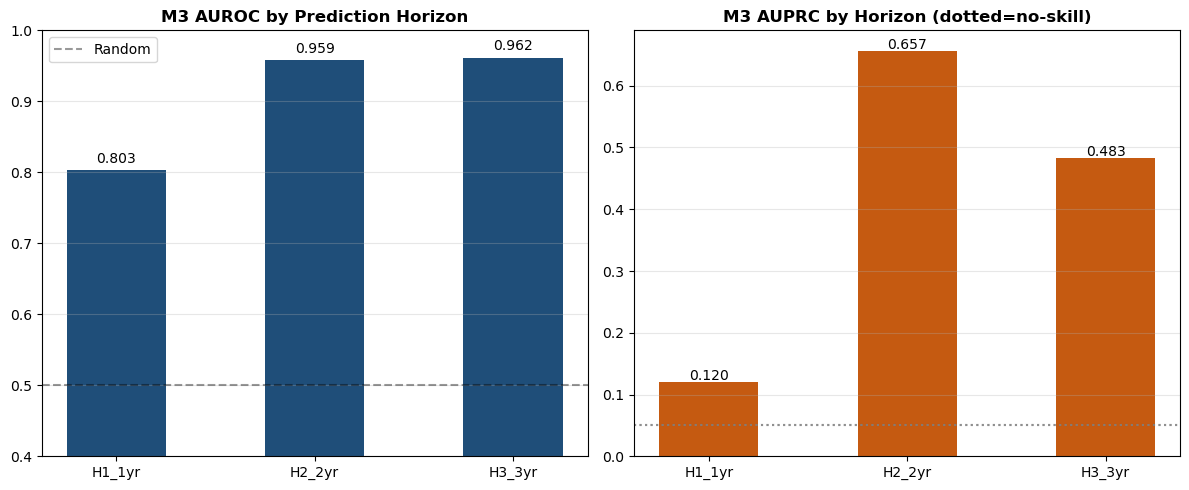

Saved fig_horizon_comparison.png


In [35]:
horizon_results = {}

for hname, htarget in [('H1_1yr','target_h1'),('H2_2yr','target_h2'),('H3_3yr','target_h3')]:
    if htarget not in df_model.columns:
        print(f'Skipping {hname}: not found'); continue
    spw = (df_model[htarget]==0).sum()/(df_model[htarget]==1).sum()
    def mh_factory(spw=spw):
        return xgb.XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,
            scale_pos_weight=spw,random_state=RANDOM_STATE,eval_metric='logloss',verbosity=0)
    print(f'Training M3 for {hname}...')
    y_h,p_h,idx_h,_ = expanding_window_cv(df_model,M3_FEATURES,htarget,mh_factory)
    if y_h.sum()==0: print(f'  No positive cases — skip'); continue
    auroc_h=roc_auc_score(y_h,p_h); auprc_h=average_precision_score(y_h,p_h)
    brier_h=brier_score_loss(y_h,p_h); base_h=y_h.mean()
    horizon_results[hname] = {'AUROC':auroc_h,'AUPRC':auprc_h,'Brier':brier_h,
                              'base_rate':base_h,'n_events':int(y_h.sum())}
    print(f'  {hname}: AUROC={auroc_h:.4f}  AUPRC={auprc_h:.4f}  base={base_h:.3f}')

print()
print('=== MULTI-HORIZON SUMMARY ===')
print(f'  {"Horizon":<12} {"AUROC":>7} {"AUPRC":>7} {"Brier":>7} {"Events":>8}')
print('  '+'-'*48)
for h,res in horizon_results.items():
    print(f'  {h:<12} {res["AUROC"]:>7.4f} {res["AUPRC"]:>7.4f} {res["Brier"]:>7.4f} {res["n_events"]:>8}')
pd.DataFrame(horizon_results).T.to_csv(OUT_DIR/'horizon_results.csv')
print(f'Saved horizon_results.csv')

# Plot horizon comparison
if len(horizon_results) >= 2:
    hnames = list(horizon_results.keys())
    aurocs = [horizon_results[h]['AUROC'] for h in hnames]
    auprcs = [horizon_results[h]['AUPRC'] for h in hnames]
    bases  = [horizon_results[h]['base_rate'] for h in hnames]
    x = np.arange(len(hnames))
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
    ax1.bar(x,aurocs,0.5,color='#1F4E79')
    ax1.axhline(0.5,color='k',linestyle='--',alpha=0.4,label='Random')
    ax1.set_xticks(x); ax1.set_xticklabels(hnames); ax1.set_ylim(0.4,1.0)
    ax1.set_title('M3 AUROC by Prediction Horizon',fontweight='bold')
    ax1.legend(); ax1.grid(True,alpha=0.3,axis='y')
    for i,v in enumerate(aurocs): ax1.text(i,v+0.01,f'{v:.3f}',ha='center',fontsize=10)
    ax2.bar(x,auprcs,0.5,color='#C55A11')
    for i,b in enumerate(bases): ax2.axhline(b,color='grey',linestyle=':',alpha=0.5)
    ax2.set_xticks(x); ax2.set_xticklabels(hnames)
    ax2.set_title('M3 AUPRC by Horizon (dotted=no-skill)',fontweight='bold')
    ax2.grid(True,alpha=0.3,axis='y')
    for i,v in enumerate(auprcs): ax2.text(i,v+0.003,f'{v:.3f}',ha='center',fontsize=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_horizon_comparison.png',dpi=150,bbox_inches='tight')
    plt.show(); print(f'Saved fig_horizon_comparison.png')

In [37]:
base_rate = df_model[TARGET].mean()
results = {
    'M1_Logistic_macro_lag1':       {'AUROC': auroc_m1, 'AUPRC': auprc_m1, 'Brier': brier_m1},
    'M2_RandomForest_macro_lag123': {'AUROC': auroc_m2, 'AUPRC': auprc_m2, 'Brier': brier_m2},
    'M3_XGBoost_sent_rolling':      {'AUROC': auroc_m3, 'AUPRC': auprc_m3, 'Brier': brier_m3},
}
print('=' * 72)
print(f' {"Model":<35} {"AUROC":>7} {"AUPRC":>7} {"AUPRC/Base":>10} {"Brier":>7}')
print('-' * 72)
for name, res in results.items():
    lift = res['AUPRC'] / base_rate
    print(f' {name:<35} {res["AUROC"]:>7.4f} {res["AUPRC"]:>7.4f} {lift:>9.1f}x {res["Brier"]:>7.4f}')
print('=' * 72)
print(f' Baseline AUPRC: {base_rate:.4f} | scale_pos_weight: {scale_pw:.1f}')
print(f' Crisis events (crisis_w2): {int(df_model[TARGET].sum())} / {len(df_model)}')
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})
results_df.to_csv(OUT_DIR / 'model_results.csv', index=False)
print(f'\nSaved → {OUT_DIR}/model_results.csv')

 Model                                 AUROC   AUPRC AUPRC/Base   Brier
------------------------------------------------------------------------
 M1_Logistic_macro_lag1               0.8761  0.2850       3.5x  0.2118
 M2_RandomForest_macro_lag123         0.9465  0.5607       6.9x  0.0506
 M3_XGBoost_sent_rolling              0.9586  0.6569       8.1x  0.0826
 Baseline AUPRC: 0.0815 | scale_pos_weight: 11.3
 Crisis events (crisis_w2): 26 / 319

Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\sentiment_improved/model_results.csv


## Cell — Calibration Plot (Reliability Diagram)

Tests whether predicted probabilities match observed event frequencies.
A well-calibrated model at threshold p should be correct p% of the time.
Critical for macroprudential use where decisions are made at specific probability thresholds.


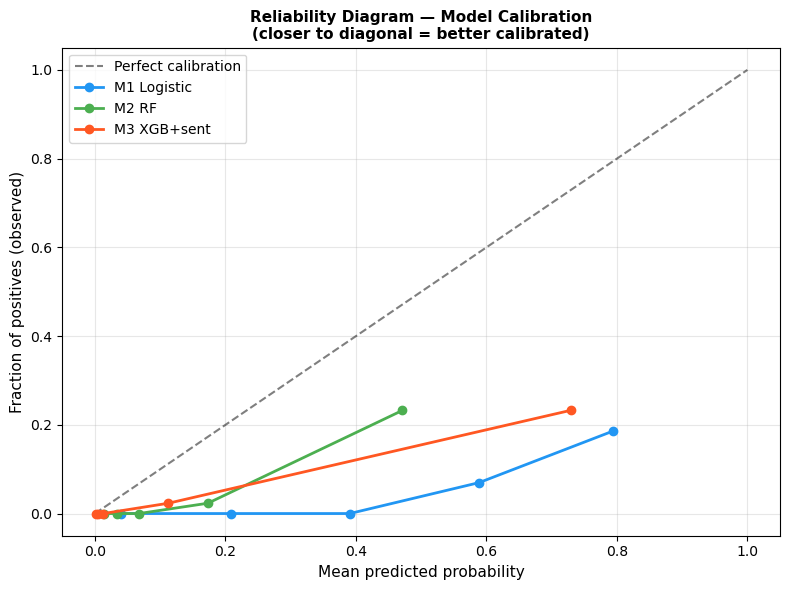

Saved calibration_plot.png

NOTE: With only 26 crisis events, calibration bins contain few positives.
Interpret as indicative rather than precise calibration evidence.


In [39]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect calibration')

colors = ['#2196F3','#4CAF50','#FF5722']
model_data_calib = [
    ('M1 Logistic', y_m1, prob_m1),
    ('M2 RF',       y_m2, prob_m2),
    ('M3 XGB+sent', y_m3, prob_m3),
]

for (name, yt, yp), color in zip(model_data_calib, colors):
    try:
        fraction_pos, mean_pred = calibration_curve(
            yt, yp, n_bins=5, strategy='quantile')
        ax.plot(mean_pred, fraction_pos, marker='o', color=color,
                lw=2, label=name)
    except Exception as e:
        print(f'Calibration failed for {name}: {e}')

ax.set_xlabel('Mean predicted probability', fontsize=11)
ax.set_ylabel('Fraction of positives (observed)', fontsize=11)
ax.set_title('Reliability Diagram — Model Calibration\n'
             '(closer to diagonal = better calibrated)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved calibration_plot.png')
print()
print('NOTE: With only 26 crisis events, calibration bins contain few positives.')
print('Interpret as indicative rather than precise calibration evidence.')

## Cell 13 — ROC and PR Curves

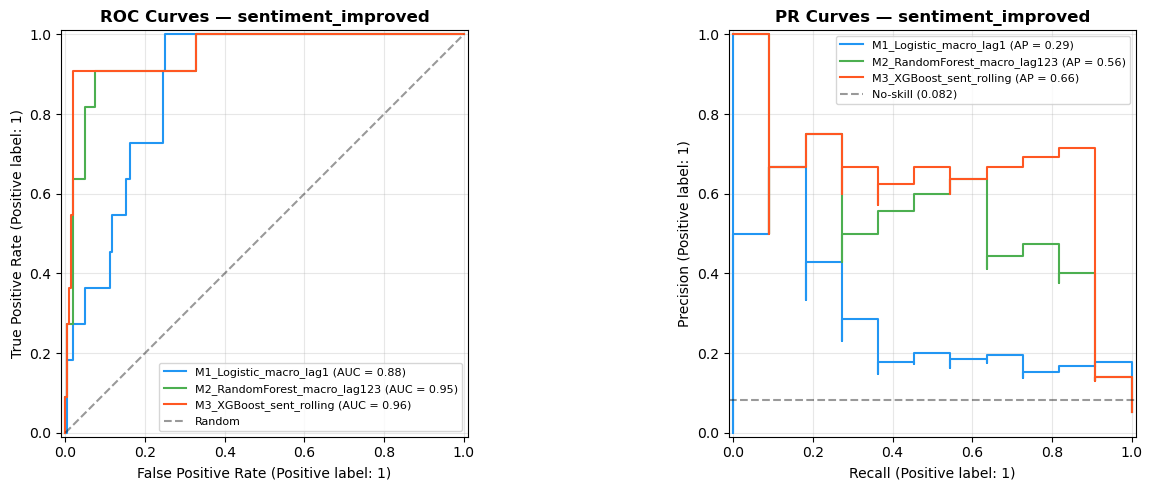

Saved → C:\Users\Owner\OneDrive\dissertation\figures\sentiment_improved/roc_pr_curves.png


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3','#4CAF50','#FF5722']
for (name, res), color, ys, probs in zip(results.items(), colors,
        [y_m1,y_m2,y_m3],[prob_m1,prob_m2,prob_m3]):
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=ax1, color=color)
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=ax2, color=color)
ax1.plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
ax1.set_title('ROC Curves — sentiment_improved', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8); ax1.grid(True, alpha=0.3)
ax2.axhline(base_rate, color='k', linestyle='--', alpha=0.4, label=f'No-skill ({base_rate:.3f})')
ax2.set_title('PR Curves — sentiment_improved', fontweight='bold')
ax2.legend(loc='upper right', fontsize=8); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/roc_pr_curves.png')

## Cell 14 — SHAP Full-Data Fit

In [43]:
X_m3  = df_model[M3_FEATURES]
y_all = df_model[TARGET]
xgb_full = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pw, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
xgb_full.fit(X_m3, y_all)
tmp = tempfile.mktemp(suffix='.json')
xgb_full.save_model(tmp); xgb_full.load_model(tmp)
import os; os.remove(tmp)
explainer   = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_m3)
print(f'SHAP shape: {shap_values.shape}')
shap_df = pd.DataFrame(shap_values, columns=M3_FEATURES)
shap_df.to_csv(OUT_DIR / 'shap_values_m3.csv', index=False)
print(f'Saved → {OUT_DIR}/shap_values_m3.csv')

SHAP shape: (319, 61)
Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\sentiment_improved/shap_values_m3.csv


## Cell 15 — SHAP Beeswarm

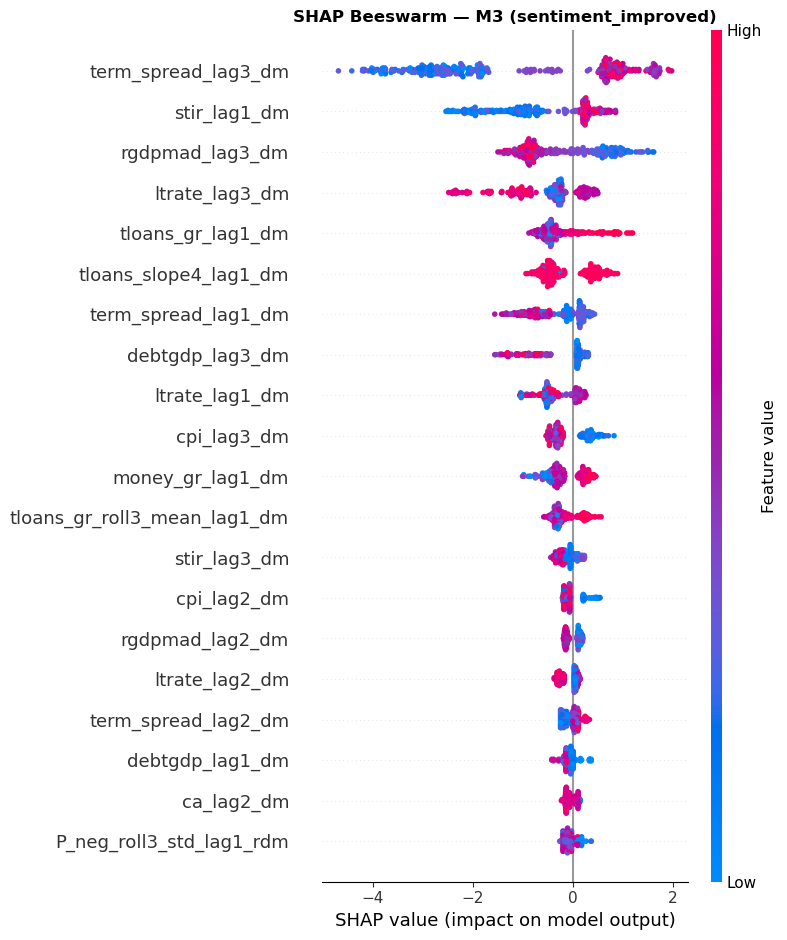

Saved → C:\Users\Owner\OneDrive\dissertation\figures\sentiment_improved/shap_summary_m3.png


In [45]:
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_m3, feature_names=M3_FEATURES, show=False, plot_type='dot')
plt.title('SHAP Beeswarm — M3 (sentiment_improved)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/shap_summary_m3.png')

## Cell 16 — SHAP by Lag Depth

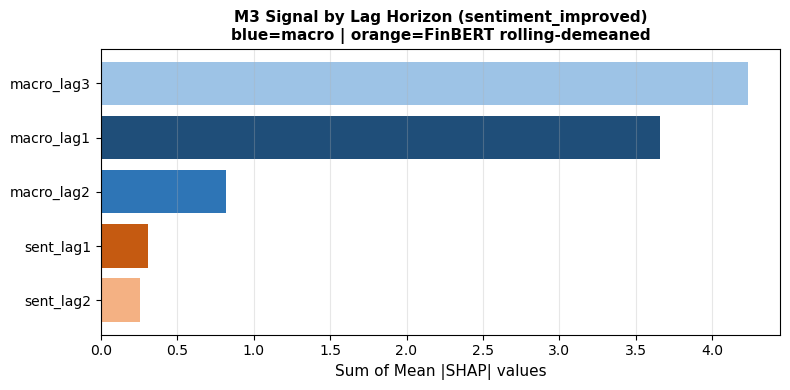

Lag group importance:
macro_lag3    4.231299
macro_lag1    3.656794
macro_lag2    0.818394
sent_lag1     0.309262
sent_lag2     0.256186


In [47]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=M3_FEATURES)
lag_importance = {grp: mean_abs_shap[[c for c in cols if c in mean_abs_shap.index]].sum()
                  for grp, cols in LAG_GROUPS.items()}
lag_series = pd.Series(lag_importance).sort_values(ascending=False)

palette = {'macro_lag1':'#1F4E79','macro_lag2':'#2E75B6','macro_lag3':'#9DC3E6',
           'sent_lag1':'#C55A11','sent_lag2':'#F4B183'}
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(lag_series.index[::-1], lag_series.values[::-1],
        color=[palette.get(g,'#999') for g in lag_series.index[::-1]])
ax.set_xlabel('Sum of Mean |SHAP| values', fontsize=11)
ax.set_title('M3 Signal by Lag Horizon (sentiment_improved)\n'
             'blue=macro | orange=FinBERT rolling-demeaned', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_by_lag_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Lag group importance:')
print(lag_series.to_string())

## Cell 17 — Per-Fold SHAP Stability

Computing fold SHAP stability (3-5 min)...
  Fold 2010: 18 obs
  Fold 2011: 18 obs
  Fold 2012: 18 obs
  Fold 2013: 18 obs
  Fold 2014: 18 obs
  Fold 2015: 18 obs
  Fold 2016: 18 obs
  Fold 2017: 18 obs
  Fold 2018: 17 obs


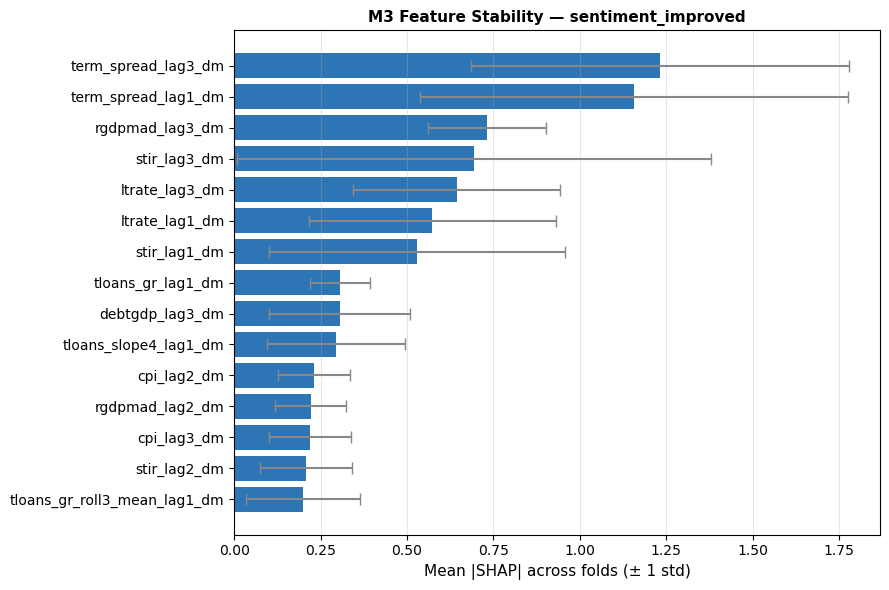

Saved → C:\Users\Owner\OneDrive\dissertation\figures\sentiment_improved/shap_fold_stability.png


In [49]:
print('Computing fold SHAP stability (3-5 min)...')
years_cv   = sorted(y for y in df_model['year'].unique() if y not in [2019,2020])
first_eval = years_cv[7]
fold_shap_list = []
for eval_yr in (y for y in years_cv if y >= first_eval):
    tr = df_model['year'] < eval_yr; te = df_model['year'] == eval_yr
    X_tr = df_model.loc[tr, M3_FEATURES]; y_tr = df_model.loc[tr, TARGET]
    X_te = df_model.loc[te, M3_FEATURES]
    if y_tr.sum() == 0 or len(X_te) == 0: continue
    m = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           scale_pos_weight=scale_pw, random_state=RANDOM_STATE,
                           eval_metric='logloss', verbosity=0)
    m.fit(X_tr, y_tr)
    tmp2 = tempfile.mktemp(suffix='.json')
    m.save_model(tmp2); m.load_model(tmp2); os.remove(tmp2)
    sv = shap.TreeExplainer(m).shap_values(X_te)
    fold_shap_list.append(pd.Series(np.abs(sv).mean(axis=0), index=M3_FEATURES))
    print(f'  Fold {eval_yr}: {len(X_te)} obs')
shap_stab = pd.DataFrame(fold_shap_list)
shap_mean = shap_stab.mean().sort_values(ascending=False)
shap_std  = shap_stab.std()
top15 = shap_mean.head(15)
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(top15.index[::-1], top15.values[::-1],
        xerr=shap_std[top15.index[::-1]].values, color='#2E75B6', ecolor='#888', capsize=4)
ax.set_xlabel('Mean |SHAP| across folds (± 1 std)', fontsize=11)
ax.set_title('M3 Feature Stability — sentiment_improved', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_fold_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/shap_fold_stability.png')

## Cell 18 — Save All Outputs

In [51]:
df_model.to_csv(OUT_DIR / 'df_model_imp.csv', index=False)
pd.Series(M1_FEATURES).to_csv(OUT_DIR / 'M1_features.csv', index=False, header=False)
pd.Series(M2_FEATURES).to_csv(OUT_DIR / 'M2_features.csv', index=False, header=False)
pd.Series(M3_FEATURES).to_csv(OUT_DIR / 'M3_features.csv', index=False, header=False)

oos_m1 = pd.Series(prob_m1, index=idx_m1, name='prob_m1')
oos_m2 = pd.Series(prob_m2, index=idx_m2, name='prob_m2')
oos_m3 = pd.Series(prob_m3, index=idx_m3, name='prob_m3')
oos_all = df_model[['year','iso',TARGET]].join(oos_m1).join(oos_m2).join(oos_m3)
oos_all.to_csv(OUT_DIR / 'oos_predictions.csv', index=False)

print('=' * 65)
print(' NOTEBOOK 05 sentiment_improved COMPLETE')
print('=' * 65)
print(f'Crisis events : {int(df_model[TARGET].sum())} | Rows : {len(df_model)}')
print()
print('CSV files:')
for f in sorted(OUT_DIR.glob('*.csv')): print(f'  {f.name}  ({f.stat().st_size//1024} KB)')
print('Figures:')
for f in sorted(FIG_DIR.glob('*.png')): print(f'  {f.name}  ({f.stat().st_size//1024} KB)')
print()
print('Ready to run 06_Results_Analysis_sentiment_improved.ipynb')

 NOTEBOOK 05 sentiment_improved COMPLETE
Crisis events : 26 | Rows : 319

CSV files:
  df_model_imp.csv  (945 KB)
  horizon_results.csv  (0 KB)
  M1_features.csv  (0 KB)
  M2_features.csv  (0 KB)
  M3_features.csv  (1 KB)
  metrics_with_ci.csv  (0 KB)
  model_results.csv  (0 KB)
  oos_predictions.csv  (16 KB)
  shap_values_m3.csv  (207 KB)
Figures:
  calibration_plot.png  (87 KB)
  fig_horizon_comparison.png  (49 KB)
  fig_sentiment_contribution_comparison.png  (51 KB)
  fig_shap_lag_depth.png  (41 KB)
  fig_shap_top20.png  (86 KB)
  fig_temporal_probs.png  (81 KB)
  granger_causality.png  (86 KB)
  roc_pr_curves.png  (106 KB)
  shap_by_lag_depth.png  (41 KB)
  shap_fold_stability.png  (79 KB)
  shap_summary_m3.png  (232 KB)

Ready to run 06_Results_Analysis_sentiment_improved.ipynb
